In [1]:
from datetime import datetime
from ib_async import *

In [2]:
# Jupyter notebook 內使用 asyncio 需要 nest_asyncio 套件，否則會出現 RuntimeError: This event loop is already running
import asyncio
import nest_asyncio

nest_asyncio.apply()

# 連線IB

In [15]:
# --- 連接設定 ---
ib = IB()
# TWS 預設 Port：模擬盤 (Paper) 為 7497，實盤 (Live) 為 7496
# IB Gateway 預設 Port：模擬盤 (Paper) 為 4002，實盤 (Live) 為 4001
ib.connect('127.0.0.1', 4002, clientId=11)

# 檢查是否成功連接
if ib.isConnected():
    print("成功連接到 IB API！")
else:
    print("連接失敗！")

# 切換市場數據模式為 Delayed-Frozen (4)
ib.reqMarketDataType(3)

成功連接到 IB API！


# 取得盤中資料

In [8]:


# 1. 建立合約並進行補全 (qualifyContracts)
contract = Stock('AAPL', 'SMART', 'USD')
ib.qualifyContracts(contract)

# 2. 請求市場數據並接收回傳物件
ticker = ib.reqMktData(contract, '', False, False)
ib.sleep(2)  # 等待數據同步

# 3. 讀取數據 (改用 marketPrice() 與 close)
print(f"股票: {contract.symbol}")
print(f"現價/市場價: {ticker.marketPrice()}")
print(f"前一交易日收盤價 (Close): {ticker.close}")
print(f"買一價 (Bid): {ticker.bid}")
print(f"賣一價 (Ask): {ticker.ask}")

股票: AAPL
現價/市場價: nan
前一交易日收盤價 (Close): nan
買一價 (Bid): nan
賣一價 (Ask): nan


# 取得歷史資料

In [5]:
# 抓取 日K 10 年歷史資料（必然能拿到收盤價，不需任何即時數據訂閱）
bars = ib.reqHistoricalData(
    contract,
    endDateTime='',
    durationStr='10 Y',
    barSizeSetting='1 day',
    whatToShow='TRADES',
    useRTH=True
)

if bars:
    print(f"最新收盤價: {bars[-1].close}")

最新收盤價: 326.57


In [8]:
# 抓取 30分K 1月 歷史資料（必然能拿到收盤價，不需任何即時數據訂閱）
bars = ib.reqHistoricalData(
    contract,
    endDateTime='',
    durationStr='1 M',
    barSizeSetting='30 mins',
    whatToShow='TRADES',
    useRTH=True
)

if bars:
    print(f"最新收盤價: {bars[-1].close}")

最新收盤價: 326.6


In [9]:
# 抓取 5分K 1週 歷史資料（必然能拿到收盤價，不需任何即時數據訂閱）
bars = ib.reqHistoricalData(
    contract,
    endDateTime='',
    durationStr='1 W',
    barSizeSetting='5 mins',
    whatToShow='TRADES',
    useRTH=True
)

if bars:
    print(f"最新收盤價: {bars[-1].close}")

最新收盤價: 326.6


In [ ]:
# 抓取 1分K 1天 歷史資料（必然能拿到收盤價，不需任何即時數據訂閱）
bars = ib.reqHistoricalData(
    contract,
    endDateTime='',
    durationStr='1 D',
    barSizeSetting='1 min',
    whatToShow='TRADES',
    useRTH=True
)

if bars:
    print(f"最新收盤價: {bars[-1].close}")

最新收盤價: 326.6


# 下單

## 普通股

In [15]:
# --- 下達訂單 ---
# 建立市價單 (Market Order) 買入 100 股 AAPL
# order = MarketOrder(
#     action='BUY',
#     totalQuantity=100,
#     tif='DAY',   # 當日有效單, 盤後掛單必填
# )
# 建立限價單 (Limit Order) 買入 100 股 AAPL，限價 $150
order = LimitOrder(
    action='BUY',
    totalQuantity=100,
    lmtPrice=150.0,
    # outsideRth=True,  # 允許盤前盤後成交
    tif='DAY'  # 當日有效, 盤後掛單必填
)

# 發送交易指令
trade = ib.placeOrder(contract, order)

# 監控訂單狀態
ib.sleep(5) # 等待訂單執行

if trade.orderStatus.status == 'Filled':
    print("訂單已成功執行！")
    print(f"成交數量: {trade.orderStatus.filled}")
    print(f"平均成交價: {trade.orderStatus.avgFillPrice}")
else:
    print(f"訂單當前狀態: {trade.orderStatus.status}")

訂單當前狀態: PreSubmitted


## 選擇權

### 裸買賣

In [61]:
# 1. 定義選擇權合約 (以 AAPL Call 為例)
contract = Option(
    symbol="AAPL",
    lastTradeDateOrContractMonth="20261016",  # 到期日
    strike=200,  # 履約價
    right="C",  # C: Call, P: Put
    exchange="SMART",
    currency="USD",
    # tif="DAY"  # 當日有效, 盤後掛單必填
)

# 2. 驗證合約 (自動填補 conId 與正確的 multiplier 等)
await ib.qualifyContractsAsync(contract)

# 3. 建立限價單 (Limit Order) - 買進 1 口，限價 $5.50
order = LimitOrder(action="BUY", totalQuantity=1, lmtPrice=5.50, tif="DAY")  # 當日有效, 盤後掛單必填

# 4. 送出訂單
trade = ib.placeOrder(contract, order)

# 監控訂單狀態
ib.sleep(5) # 等待訂單執行

if trade.orderStatus.status == 'Filled':
    print("訂單已成功執行！")
    print(f"成交數量: {trade.orderStatus.filled}")
    print(f"平均成交價: {trade.orderStatus.avgFillPrice}")
else:
    print(f"訂單當前狀態: {trade.orderStatus.status}")

IBKR API validation warning: Trade(contract=Option(conId=855958572, symbol='AAPL', lastTradeDateOrContractMonth='20261016', strike=200.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261016C00200000', tradingClass='AAPL'), order=LimitOrder(orderId=73, clientId=5, permId=22830335, action='BUY', totalQuantity=1.0, lmtPrice=5.5, auxPrice=0.0, tif='DAY'), orderStatus=OrderStatus(orderId=73, status='ValidationError', filled=0.0, remaining=1.0, avgFillPrice=0.0, permId=22830335, parentId=0, lastFillPrice=0.0, clientId=5, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 6, 41, 59759, tzinfo=datetime.timezone.utc), status='PendingSubmit', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 6, 41, 295288, tzinfo=datetime.timezone.utc), status='PreSubmitted', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 6, 41, 297287, tzinfo=datetime.timezone.utc), st

訂單當前狀態: PreSubmitted


### 複式單

In [65]:
# 1. 定義兩腳單獨的選擇權合約
leg1_contract = Option("AAPL", "20261016", 200, "C", "SMART")
leg2_contract = Option("AAPL", "20261016", 210, "C", "SMART")

# 必須先取得兩腳的 conId
await ib.qualifyContractsAsync(leg1_contract, leg2_contract)

# 2. 建立 ComboLeg 物件
# action: 'BUY' 或 'SELL'
# ratio: 比例 (例如 1:1 價差)
leg1 = ComboLeg(
    conId=leg1_contract.conId,
    ratio=1,
    action="BUY",
    exchange="SMART",
)
leg2 = ComboLeg(
    conId=leg2_contract.conId,
    ratio=1,
    action="SELL",
    exchange="SMART",
)

# 3. 建立 BAG (Combo) 組合合約
combo_contract = Contract(
    symbol="AAPL",
    secType="BAG",
    currency="USD",
    exchange="SMART",
    comboLegs=[leg1, leg2],
)

# 4. 建立價差限價單
# 注意： action="BUY" 表示買進這個價差組合，lmtPrice 為「淨權利金 (Net Debit/Credit)」
# 正數表示支出權利金 (Debit)，負數表示收取權利金 (Credit)
order = LimitOrder(
    action="BUY",
    totalQuantity=1,
    lmtPrice=2.30,  # 預計淨支出 $2.30 買進此價差組合
    tif="DAY"
)

# 5. 送出訂單
trade = ib.placeOrder(combo_contract, order)
print(f"Combo Order placed ID: {trade.order.orderId}")

# 監控訂單狀態
ib.sleep(5) # 等待訂單執行

if trade.orderStatus.status == 'Filled':
    print("訂單已成功執行！")
    print(f"成交數量: {trade.orderStatus.filled}")
    print(f"平均成交價: {trade.orderStatus.avgFillPrice}")
else:
    print(f"訂單當前狀態: {trade.orderStatus.status}")

Combo Order placed ID: 82


IBKR API validation warning: Trade(contract=Contract(secType='BAG', symbol='AAPL', exchange='SMART', currency='USD', comboLegs=[ComboLeg(conId=855958572, ratio=1, action='BUY', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1), ComboLeg(conId=855958602, ratio=1, action='SELL', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1)]), order=LimitOrder(orderId=82, clientId=5, permId=22830336, action='BUY', totalQuantity=1.0, lmtPrice=2.3, auxPrice=0.0, tif='DAY'), orderStatus=OrderStatus(orderId=82, status='ValidationError', filled=0.0, remaining=1.0, avgFillPrice=0.0, permId=22830336, parentId=0, lastFillPrice=0.0, clientId=5, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 9, 24, 838166, tzinfo=datetime.timezone.utc), status='PendingSubmit', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 9, 27, 243125, tzinfo=datetime.timezone.utc), status

訂單當前狀態: PreSubmitted


## 改價

In [67]:
# 關鍵：再次對「同一個 contract 與 order」呼叫 placeOrder
# 因為 order.orderId 沒有變，IB 會自動轉為修改訂單
order.lmtPrice = 5.75
new_trade = ib.placeOrder(contract, order)

ib.sleep(5)
print(f"修改後狀態: {new_trade.orderStatus.status}, 新價格: {new_trade.order.lmtPrice}")

IBKR API validation warning: Trade(contract=Contract(secType='BAG', symbol='AAPL', exchange='SMART', currency='USD', comboLegs=[ComboLeg(conId=855958572, ratio=1, action='BUY', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1), ComboLeg(conId=855958602, ratio=1, action='SELL', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1)]), order=LimitOrder(orderId=82, clientId=5, permId=22830336, action='BUY', totalQuantity=1.0, lmtPrice=5.75, auxPrice=0.0, tif='DAY'), orderStatus=OrderStatus(orderId=82, status='ValidationError', filled=0.0, remaining=1.0, avgFillPrice=0.0, permId=22830336, parentId=0, lastFillPrice=0.0, clientId=5, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 9, 24, 838166, tzinfo=datetime.timezone.utc), status='PendingSubmit', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 9, 27, 243125, tzinfo=datetime.timezone.utc), statu

修改後狀態: ValidationError, 新價格: 5.75


## 刪單

In [68]:
ib.cancelOrder(order)

Trade(contract=Contract(secType='BAG', symbol='AAPL', exchange='SMART', currency='USD', comboLegs=[ComboLeg(conId=855958572, ratio=1, action='BUY', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1), ComboLeg(conId=855958602, ratio=1, action='SELL', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1)]), order=LimitOrder(orderId=82, clientId=5, permId=22830336, action='BUY', totalQuantity=1.0, lmtPrice=5.75, auxPrice=0.0, tif='DAY'), orderStatus=OrderStatus(orderId=82, status='PendingCancel', filled=0.0, remaining=1.0, avgFillPrice=0.0, permId=22830336, parentId=0, lastFillPrice=0.0, clientId=5, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 9, 24, 838166, tzinfo=datetime.timezone.utc), status='PendingSubmit', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 9, 11, 9, 9, 27, 243125, tzinfo=datetime.timezone.utc), status='PreSubmitted', message='', e

Error 202, reqId 82: Order Canceled - reason:


* 可以利用order.orderRef來追蹤訂單, 用在專案的群組功能等等

# 查詢帳戶權益

In [6]:
summary = ib.accountSummary()
summary

[AccountValue(account='DUT110621', tag='AccountType', value='INDIVIDUAL', currency='', modelCode=''),
 AccountValue(account='DUT110621', tag='Cushion', value='1', currency='', modelCode=''),
 AccountValue(account='DUT110621', tag='LookAheadNextChange', value='0', currency='', modelCode=''),
 AccountValue(account='DUT110621', tag='AccruedCash', value='0.00', currency='USD', modelCode=''),
 AccountValue(account='DUT110621', tag='AvailableFunds', value='1000000.00', currency='USD', modelCode=''),
 AccountValue(account='DUT110621', tag='BuyingPower', value='4000000.00', currency='USD', modelCode=''),
 AccountValue(account='DUT110621', tag='EquityWithLoanValue', value='1000000.00', currency='USD', modelCode=''),
 AccountValue(account='DUT110621', tag='ExcessLiquidity', value='1000000.00', currency='USD', modelCode=''),
 AccountValue(account='DUT110621', tag='FullAvailableFunds', value='1000000.00', currency='USD', modelCode=''),
 AccountValue(account='DUT110621', tag='FullExcessLiquidity', 

# 查詢委託

In [7]:
ib.openTrades()

[Trade(contract=Stock(conId=265598, symbol='AAPL', right='?', exchange='SMART', currency='USD', localSymbol='AAPL', tradingClass='NMS'), order=Order(orderId=13, clientId=1, permId=22830332, action='BUY', totalQuantity=100.0, orderType='LMT', lmtPrice=150.0, auxPrice=0.0, tif='DAY', ocaType=3, displaySize=2147483647, rule80A='0', openClose='', volatilityType=0, deltaNeutralOrderType='無', referencePriceType=0, account='DUT110621', clearingIntent='IB', adjustedOrderType='無', cashQty=0.0, dontUseAutoPriceForHedge=True), orderStatus=OrderStatus(orderId=13, status='PreSubmitted', filled=0.0, remaining=100.0, avgFillPrice=0.0, permId=22830332, parentId=0, lastFillPrice=0.0, clientId=1, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 9, 11, 10, 35, 33, 443934, tzinfo=datetime.timezone.utc), status='PreSubmitted', message='', errorCode=0)], advancedError=''),
 Trade(contract=Stock(conId=265598, symbol='AAPL', right='?', exchange='SMART', currency='USD', l

# 查詢成交

In [8]:
ib.fills()

[]

# 查詢所有未平倉部位

In [9]:
positions = ib.positions()
positions

[]

In [10]:
def on_position_change(position):
    print(f"部位更新 -> {position.contract.symbol}: 數量 {position.position}")

# 綁定持倉變動事件
ib.positionEvent += on_position_change

# 選擇權篩選
目標: 做到如下圖類似的選擇權篩選器
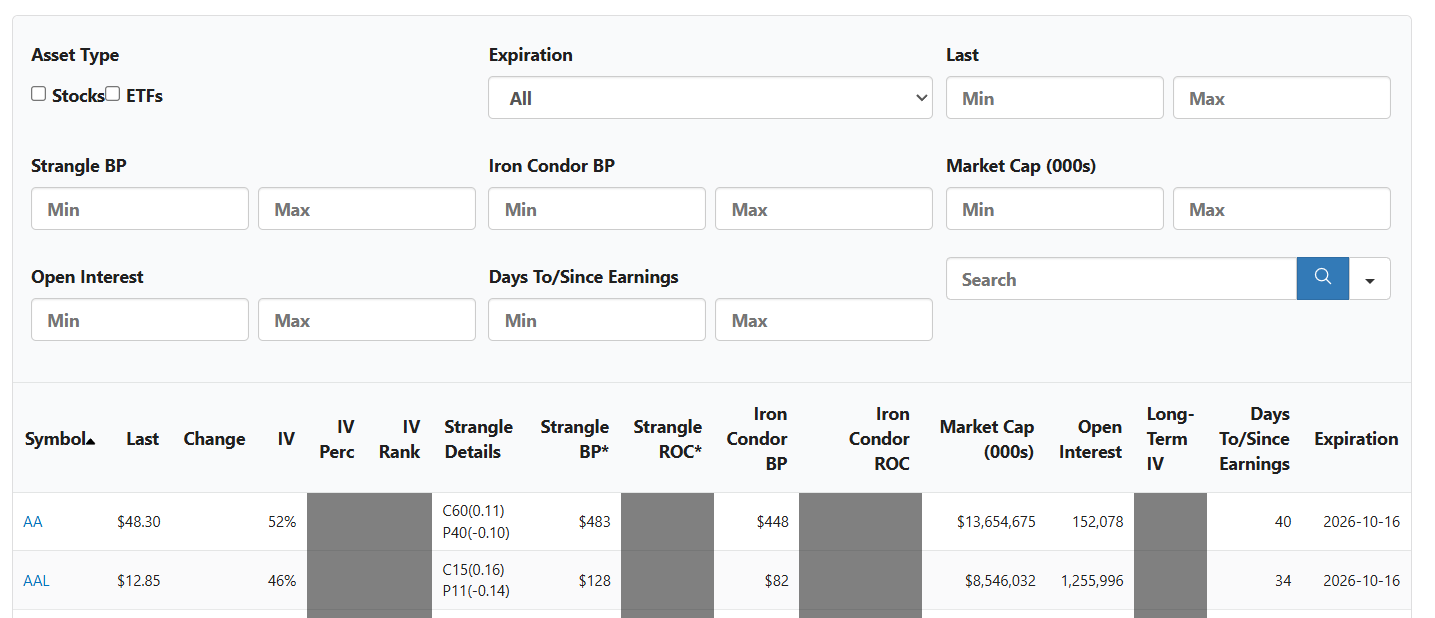

## 初篩

In [ ]:
# 可以選擇的參數要查這裡
parameters = await ib.reqScannerParametersAsync()
with open("scanner_parameters.xml", "w") as f:
    f.write(parameters)

Peer closed connection.


In [12]:
# 1. 建立基礎 ScannerSubscription 物件 (先實例化，再設定基本欄位)
sub = ScannerSubscription()
sub.instrument = "STK"
sub.locationCode = "STK.US.MAJOR"
sub.scanCode = "HIGH_OPT_IMP_VOLAT"  # 高隱含波動率 (配合 Sell Option 策略)

# 2. 將數值篩選條件寫入 TagValue List
# 欄位名稱需精確匹配 TWS API 規範：
# - priceAbove / priceBelow (股價)
# - marketCapAbove / marketCapBelow (市值，單位為美元)
# - volumeAbove (成交量)
scanner_filters = [
    TagValue(tag='priceAbove', value='10'),            # 股價 > $10
    TagValue(tag='priceBelow', value='100'),           # 股價 < $100
    TagValue(tag='marketCapAbove1e6', value='1000'),   # 市值 > 10 億美元 (1000M)
    TagValue(tag='optVolumeAbove', value='1000') # 期權平均成交量 > 1000
]

# 3. 將 scanner_filters 透過 scannerSubscriptionFilterOptions 帶入呼叫
scan_results = ib.reqScannerSubscription(
    sub, 
    scannerSubscriptionFilterOptions=scanner_filters
)

Error 162, reqId 8: Historical Market Data Service error message:\u932f\u8aa4\uff1a\u5176\u4e2d\u4e00\u500b\u9078\u5b9a\u5730\u9ede\u6c92\u6709\u914d\u7f6e\u5e02\u5834\u6383\u63cf\u5100\u3002


## 復篩

In [32]:
contracts = [item.contractDetails.contract for item in scan_results]
ib.qualifyContracts(*contracts)

[]

In [25]:
# 針對篩選出來的股票抓取即時 IV 與價格數據(盤中, 以第一筆為例)
for contract in contracts:
    ticker = ib.reqMktData(contract, genericTickList='106', snapshot=True)
    ib.sleep(2)

    print(f"\n[{contract.symbol}] 即時市場數據範例:")
    print(f"現價 (Last): {ticker.last}")
    print(f"期權隱含波動率 (IV): {ticker.impliedVolatility}")
    break


[SLS] 即時市場數據範例:
現價 (Last): nan
期權隱含波動率 (IV): nan


In [26]:
# 針對篩選出來的股票抓取歷史 IV 與價格數據(盤後, 以第一筆為例)
for contract in contracts:
    # 1. 抓取價格歷史資料 (TRADES)
    bars_price = await ib.reqHistoricalDataAsync(
        contract,
        endDateTime='',
        durationStr='1 D',
        barSizeSetting='1 day',
        whatToShow='TRADES',
        useRTH=False,  # 設定包含盤後交易時間
        formatDate=1
    )

    # 2. 抓取隱含波動率歷史資料 (OPTION_IMPLIED_VOLATILITY)
    bars_iv = await ib.reqHistoricalDataAsync(
        contract,
        endDateTime='',
        durationStr='1 D',
        barSizeSetting='1 day',
        whatToShow='OPTION_IMPLIED_VOLATILITY',
        useRTH=False,
        formatDate=1
    )

    print(f"\n[{contract.symbol}] 歷史市場數據範例:")
    if bars_price:
        print(f"最新收盤價: {bars_price[-1].close}")
    if bars_iv:
        print(f"最新隱含波動率 (IV): {bars_iv[-1].close}")

    break



[SLS] 歷史市場數據範例:
最新收盤價: 13.51
最新隱含波動率 (IV): 1.73984606


# 從單一股票取得期權鏈、取得報價

In [39]:

## 選擇權鏈 + 二次篩選

from datetime import datetime

# --- 篩選參數 ---
MIN_DTE = 20              # 最少距到期天數
MAX_DTE = 45              # 最多距到期天數
STRIKES_AROUND_ATM = 5    # ATM 左右各抓幾檔履約價
MAX_SPREAD_PCT = 15.0     # 買賣價差超過中價的幾% 就濾掉(流動性太差)
MIN_IV = 0.0              # 隱含波動率下限，不需要可以留 0


def get_option_chain(ib, stock_contract):
    """查一檔股票的選擇權鏈；只取 SMART + tradingClass 跟 symbol 同名那組，
    避開個別交易所各自重複列一次、以及除息調整後的特殊 tradingClass(例如 "2AAPL")。"""
    chains = ib.reqSecDefOptParams(stock_contract.symbol, '', 'STK', stock_contract.conId)
    for c in chains:
        if c.exchange == 'SMART' and c.tradingClass == stock_contract.symbol:
            return c
    return None


def pick_expiry(chain, min_dte=MIN_DTE, max_dte=MAX_DTE):
    """從到期日清單挑落在 [min_dte, max_dte] 天數區間內、最接近 min_dte 的一個。"""
    today = datetime.now()
    candidates = sorted(
        (dte, exp)
        for exp in chain.expirations
        if min_dte <= (dte := (datetime.strptime(exp, '%Y%m%d') - today).days) <= max_dte
    )
    return candidates[0][1] if candidates else None


def get_underlying_price(ib, stock_contract):
    """拿標的參考價：先試即時報價，拿不到(nan，帳戶還沒開通即時/延遲訂閱時會這樣)
    就退回昨收(歷史資料，這條路目前確認可用)。"""
    ticker = ib.reqMktData(stock_contract, '', False, False)
    ib.sleep(2)
    price = ticker.marketPrice()
    ib.cancelMktData(stock_contract)
    if price == price:  # nan != nan，這樣寫可以排除 nan
        return price
    bars = ib.reqHistoricalData(
        stock_contract, endDateTime='', durationStr='1 D',
        barSizeSetting='1 day', whatToShow='TRADES', useRTH=True,
    )
    return bars[-1].close if bars else None


def pick_strikes_near_atm(chain, underlying_price, n=STRIKES_AROUND_ATM):
    strikes = sorted(chain.strikes)
    if not strikes or underlying_price is None:
        return []
    center = min(strikes, key=lambda s: abs(s - underlying_price))
    idx = strikes.index(center)
    return strikes[max(0, idx - n): idx + n + 1]

def screen_options(ib, stock_contract, right='C'):
    """對一檔候選股票跑完整流程：查選擇權鏈 → 挑到期日/履約價 → 用即時報價
    (bid/ask/IV)做二次篩選。回傳通過篩選的合約清單(dict 帶報價欄位方便排序)。"""
    chain = get_option_chain(ib, stock_contract)
    if chain is None:
        print(f"[{stock_contract.symbol}] 查無選擇權鏈，跳過")
        return []

    expiry = pick_expiry(chain)
    if expiry is None:
        print(f"[{stock_contract.symbol}] 找不到 {MIN_DTE}~{MAX_DTE} 天內的到期日，跳過")
        return []

    price = get_underlying_price(ib, stock_contract)
    strikes = pick_strikes_near_atm(chain, price)
    if not strikes:
        print(f"[{stock_contract.symbol}] 拿不到參考價/履約價，跳過")
        return []

    option_contracts = [
        Option(stock_contract.symbol, expiry, strike, right, 'SMART', currency='USD')
        for strike in strikes
    ]
    ib.qualifyContracts(*option_contracts)

    # 這裡是這次炸掉的根因：履約價清單是「整個標的所有到期日的合集」，不保證這個 expiry 真的有這個履約價掛牌——qualifyContracts
    # 查無此合約時不會丟例外，只是 conId 留空(=0)，沒濾掉的話後面 reqMktData 會因為合約沒有 conId 而丟 ValueError(不能 hash)。
    qualified = [opt for opt in option_contracts if opt.conId]
    skipped = len(option_contracts) - len(qualified)
    if skipped:
        print(f"[{stock_contract.symbol}] {skipped} 檔履約價在 {expiry} 這個到期日查無此合約，已跳過")
    if not qualified:
        print(f"[{stock_contract.symbol}] 這個到期日沒有任何一檔履約價查得到合約，跳過")
        return []

    print(f"[{stock_contract.symbol}] 標的價≈{price} 到期日={expiry} "
          f"實際可查詢履約價={[o.strike for o in qualified]}")

    return qualified
    # for opt in qualified:
    #     ib.reqMktData(opt, genericTickList='106', snapshot=False)
    # ib.sleep(3)

    # results = []
    # for opt in qualified:
    #     ticker = ib.ticker(opt)
    #     ib.cancelMktData(opt)
    #     if ticker is None:
    #         continue

    #     bid, ask, iv = ticker.bid, ticker.ask, ticker.impliedVolatility
    #     if bid != bid or ask != ask:
    #         continue
    #     mid = (bid + ask) / 2
    #     spread_pct = (ask - bid) / mid * 100 if mid else None
    #     if spread_pct is not None and spread_pct > MAX_SPREAD_PCT:
    #         continue
    #     if iv == iv and iv < MIN_IV:
    #         continue

    #     results.append({
    #         'symbol': stock_contract.symbol, 'contract': opt, 'localSymbol': opt.localSymbol,
    #         'bid': bid, 'ask': ask, 'spread_pct': spread_pct, 'iv': iv,
    #     })
    # return results

In [37]:
contract = Stock('AAPL', 'SMART', 'USD')
ib.qualifyContracts(contract)

[Stock(conId=265598, symbol='AAPL', exchange='SMART', primaryExchange='NASDAQ', currency='USD', localSymbol='AAPL', tradingClass='NMS')]

In [41]:
qualified = screen_options(ib, contract, right='C')

Error 200, reqId 50: No security definition has been found for the request, contract: Option(symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=312.5, right='C', exchange='SMART', currency='USD')
Error 200, reqId 52: No security definition has been found for the request, contract: Option(symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=317.5, right='C', exchange='SMART', currency='USD')
Error 200, reqId 54: No security definition has been found for the request, contract: Option(symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=322.5, right='C', exchange='SMART', currency='USD')
Error 200, reqId 56: No security definition has been found for the request, contract: Option(symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=327.5, right='C', exchange='SMART', currency='USD')
Error 200, reqId 58: No security definition has been found for the request, contract: Option(symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=332.5, right

[AAPL] 6 檔履約價在 20261002 這個到期日查無此合約，已跳過
[AAPL] 標的價≈326.14 到期日=20261002 實際可查詢履約價=[315.0, 320.0, 325.0, 330.0, 335.0]


In [42]:
qualified

[Option(conId=910500693, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=315.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261002C00315000', tradingClass='AAPL'),
 Option(conId=910500722, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=320.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261002C00320000', tradingClass='AAPL'),
 Option(conId=910500758, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=325.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261002C00325000', tradingClass='AAPL'),
 Option(conId=910500783, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=330.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261002C00330000', tradingClass='AAPL'),
 Option(conId=910500809, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=335.0, right='C', multiplier='100', exchange

In [50]:
for opt in qualified:
    bar = ib.reqHistoricalData(
        contract,
        endDateTime='',
        durationStr='1 M',
        barSizeSetting='30 mins',
        whatToShow='TRADES',
        useRTH=True
    )
    ticker = ib.ticker(opt)
    iv = ib.reqMktData(opt, genericTickList='106')
    break

Error 10090, reqId 66: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.AAPL NASDAQ.NMS/TOP/ALL, contract: Option(conId=910500693, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=315.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261002C00315000', tradingClass='AAPL')


In [ ]:
ticker

nan

In [51]:
iv

Ticker(contract=Option(conId=910500693, symbol='AAPL', lastTradeDateOrContractMonth='20261002', strike=315.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='AAPL  261002C00315000', tradingClass='AAPL'), time=datetime.datetime(2026, 9, 11, 13, 13, 51, 246957, tzinfo=datetime.timezone.utc), timestamp=1789132431.2469578, marketDataType=4, minTick=0.01, bid=15.75, bidSize=325.0, ask=16.4, askSize=281.0, last=-1, lastSize=0, prevBid=15.75, prevBidSize=325.0, prevAsk=16.4, prevAskSize=281.0, volume=0.0, open=0.0, close=15.99, bidGreeks=OptionComputation(tickAttrib=0, impliedVol=None, delta=None, optPrice=None, pvDividend=0.0, gamma=None, vega=-2.0, theta=-2.0, undPrice=326.595), askGreeks=OptionComputation(tickAttrib=0, impliedVol=None, delta=None, optPrice=None, pvDividend=0.0, gamma=None, vega=-2.0, theta=-2.0, undPrice=326.595), lastGreeks=OptionComputation(tickAttrib=0, impliedVol=None, delta=None, optPrice=None, pvDividend=0.0, gamma=None, vega=-2.0, theta=-

In [ ]:
bar

[BarData(date=datetime.datetime(2026, 8, 12, 9, 30, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=305.09, high=305.66, low=302.18, close=303.36, volume=3332249.0, average=303.549, barCount=25702),
 BarData(date=datetime.datetime(2026, 8, 12, 10, 0, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=303.38, high=304.32, low=302.26, close=302.34, volume=2413640.0, average=303.016, barCount=20097),
 BarData(date=datetime.datetime(2026, 8, 12, 10, 30, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=302.35, high=303.19, low=302.06, close=302.43, volume=2025909.0, average=302.677, barCount=18421),
 BarData(date=datetime.datetime(2026, 8, 12, 11, 0, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=302.43, high=302.83, low=301.03, close=301.08, volume=1933065.0, average=301.734, barCount=17475),
 BarData(date=datetime.datetime(2026, 8, 12, 11, 30, tzinfo=zoneinfo.ZoneInfo(key='US/Eastern')), open=301.09, high=301.29, low=300.57, close=301.17, volume=1563017.0, average=300.917, barCount=1

In [13]:
ib.disconnect()

'Disconnecting from 127.0.0.1:4002, 655 B sent in 17 messages, 3.54 MB received in 1240 messages, session time 3.29 ks.'